In [ ]:
# visualization of the features after applying PCA

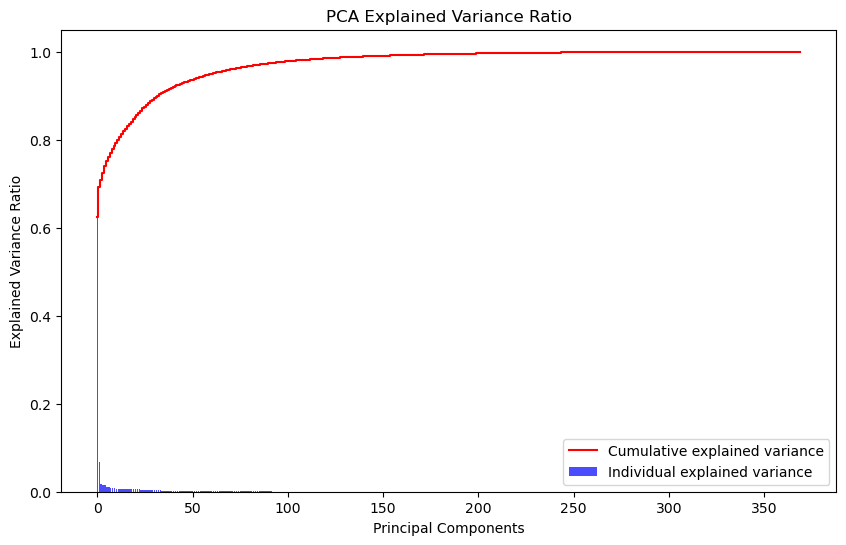

In [1]:
import numpy as np
import pandas as pd
import pywt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import cv2
import os
from skimage.feature import local_binary_pattern
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# Constants
IMAGE_SIZE = (128, 128)
RADIUS = 1
POINTS = 8
NUM_BINS = 128

# Load and preprocess images
def load_data(directory):
    data = []
    labels = []
    label_names = sorted(os.listdir(directory))
    for label in label_names:
        class_dir = os.path.join(directory, label)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, IMAGE_SIZE)
                data.append(img)
                labels.append(label_names.index(label))
    return np.array(data), np.array(labels), label_names

# Augment data
def augment_data(data, labels):
    augmented_data = []
    augmented_labels = []
    for img, label in zip(data, labels):
        augmented_data.append(img)
        augmented_labels.append(label)
        flipped = cv2.flip(img, 1)
        augmented_data.append(flipped)
        augmented_labels.append(label)
        rows, cols, _ = img.shape
        M = cv2.getRotationMatrix2D((cols/2, rows/2), 15, 1)
        rotated = cv2.warpAffine(img, M, (cols, rows))
        augmented_data.append(rotated)
        augmented_labels.append(label)
        noise = np.random.normal(0, 25, img.shape).astype(np.uint8)
        noisy = cv2.add(img, noise)
        augmented_data.append(noisy)
        augmented_labels.append(label)
    augmented_data, augmented_labels = shuffle(augmented_data, augmented_labels, random_state=42)
    return np.array(augmented_data), np.array(augmented_labels)

# Feature extraction functions
def calculate_lbp_for_channel(img_channel):
    lbp_img = local_binary_pattern(img_channel, POINTS, RADIUS, method='uniform')
    return lbp_img

def calculate_ldp_for_channel(img_channel):
    gradients = [cv2.Sobel(img_channel, cv2.CV_64F, 1, 0, ksize=3), cv2.Sobel(img_channel, cv2.CV_64F, 0, 1, ksize=3)]
    directions = np.arctan2(gradients[1], gradients[0]) * 180 / np.pi
    ldp_img = np.zeros_like(img_channel)
    for angle in [0, 45, 90, 135]:
        pattern = (directions >= angle - 22.5) & (directions < angle + 22.5)
        ldp_img += pattern.astype(np.uint8)
    return ldp_img

def calculate_dwt_for_channel(img_channel):
    coeffs = pywt.dwt2(img_channel, 'haar')
    cA, (cH, cV, cD) = coeffs
    return cA

def calculate_hough_transform(img_channel):
    edges = cv2.Canny(img_channel, 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 100)
    hough_img = np.zeros_like(img_channel)
    if lines is not None:
        for rho, theta in lines[:, 0]:
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * a)
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 + 1000 * a)
            cv2.line(hough_img, (x1, y1), (x2, y2), 255, 1)
    return hough_img

def calculate_dft_for_channel(img_channel):
    dft = cv2.dft(np.float32(img_channel), flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)
    return magnitude_spectrum

def calculate_bwt_for_channel(img_channel, block_size=8):
    blocks = [img_channel[y:y+block_size, x:x+block_size] for x in range(0, img_channel.shape[1], block_size) for y in range(0, img_channel.shape[0], block_size)]
    block_means = [np.mean(block) for block in blocks]
    block_means = np.array(block_means).reshape((img_channel.shape[0] // block_size, img_channel.shape[1] // block_size))
    return block_means

def calculate_gabor_for_channel(img_channel):
    gabor_kernels = []
    for theta in np.arange(0, np.pi, np.pi / 4):
        for sigma in (1, 3):
            kernel = cv2.getGaborKernel((15, 15), sigma, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
            gabor_kernels.append(kernel)
    
    gabor_features = []
    for kernel in gabor_kernels:
        filtered_img = cv2.filter2D(img_channel, cv2.CV_8UC3, kernel)
        gabor_features.append(filtered_img)
    
    return np.array(gabor_features)

# Extract features
def extract_features(data):
    features = []
    for img in data:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        lbp = calculate_lbp_for_channel(gray_img)
        ldp = calculate_ldp_for_channel(gray_img)
        dwt = calculate_dwt_for_channel(gray_img)
        hough = calculate_hough_transform(gray_img)
        dft = calculate_dft_for_channel(gray_img)
        bwt = calculate_bwt_for_channel(gray_img)
        gabor = calculate_gabor_for_channel(gray_img)
        
        lbp_hist, _ = np.histogram(lbp, bins=NUM_BINS, range=(0, NUM_BINS))
        ldp_hist, _ = np.histogram(ldp, bins=NUM_BINS, range=(0, NUM_BINS))
        dwt_hist, _ = np.histogram(dwt, bins=NUM_BINS, range=(0, NUM_BINS))
        hough_hist, _ = np.histogram(hough, bins=NUM_BINS, range=(0, NUM_BINS))
        dft_hist, _ = np.histogram(dft, bins=NUM_BINS, range=(0, NUM_BINS))
        bwt_hist, _ = np.histogram(bwt, bins=NUM_BINS, range=(0, NUM_BINS))
        gabor_hist, _ = np.histogram(gabor, bins=NUM_BINS, range=(0, NUM_BINS))
        
        lbp_hist = lbp_hist.astype('float') / lbp_hist.sum() if lbp_hist.sum() != 0 else lbp_hist
        ldp_hist = ldp_hist.astype('float') / ldp_hist.sum() if ldp_hist.sum() != 0 else ldp_hist
        dwt_hist = dwt_hist.astype('float') / dwt_hist.sum() if dwt_hist.sum() != 0 else dwt_hist
        hough_hist = hough_hist.astype('float') / hough_hist.sum() if hough_hist.sum() != 0 else hough_hist
        dft_hist = dft_hist.astype('float') / dft_hist.sum() if dft_hist.sum() != 0 else dft_hist
        bwt_hist = bwt_hist.astype('float') / bwt_hist.sum() if bwt_hist.sum() != 0 else bwt_hist
        gabor_hist = gabor_hist.astype('float') / gabor_hist.sum() if gabor_hist.sum() != 0 else gabor_hist
        
        features.append(np.concatenate((lbp_hist, ldp_hist, dwt_hist, hough_hist, dft_hist, bwt_hist, gabor_hist)))
    return np.array(features)

# Main code
directory = r'C:\Users\KIIT\Desktop\Disease_Prediction-20231213T083430Z-001\Disease_Prediction'

images, labels, label_names = load_data(directory)

# Augment data
images, labels = augment_data(images, labels)

# Extract features
features = extract_features(images)

pca = PCA(n_components=370)  # Adjust n_components as needed
features_pca = pca.fit_transform(features)
explained_variance = pca.explained_variance_ratio_

# Visualization of PCA explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(len(explained_variance)), explained_variance, alpha=0.7, color='b', label='Individual explained variance')
plt.step(range(len(explained_variance)), np.cumsum(explained_variance), where='mid', color='r', label='Cumulative explained variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.legend(loc='best')
plt.show()


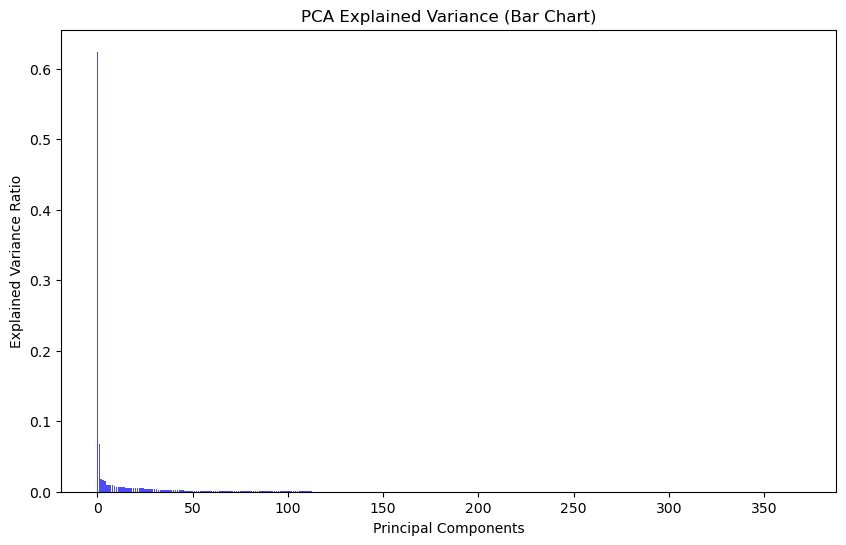

In [2]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(explained_variance)), explained_variance, alpha=0.7, color='b', label='Individual explained variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (Bar Chart)')
plt.show()


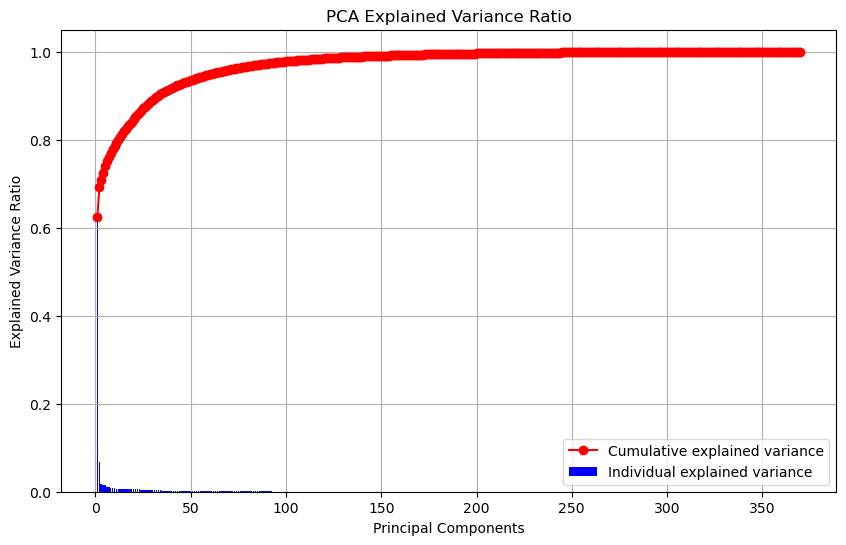

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Generate the bar plot for individual explained variance
plt.figure(figsize=(10, 6))
components = np.arange(1, len(pca.explained_variance_ratio_) + 1)

# Plot the individual explained variance as bars
plt.bar(components, pca.explained_variance_ratio_, color='blue', label='Individual explained variance')

# Plot the cumulative explained variance as a line
plt.plot(components, np.cumsum(pca.explained_variance_ratio_), color='red', marker='o', linestyle='-', label='Cumulative explained variance')

# Labels and title
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')

# Adding a grid and legend
plt.grid(True)
plt.legend(loc='best')

# Display the plot
plt.show()


In [5]:
# Assuming 'pca' is your PCA object and you've already transformed your data
# Replace 'X' with the variable that contains your original data before PCA
pca_components = pca.transform(X)

# Scatter plot for the first two principal components
plt.figure(figsize=(10, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c='blue', edgecolor='k', s=50)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA - First Two Principal Components')
plt.grid(True)
plt.show()



NameError: name 'X' is not defined

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features_pca, labels, test_size=0.3, random_state=42)

# Train and evaluate classifiers
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(iterations=100, verbose=0, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42)
}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {accuracy:.4f}')
